In [ ]:
# load the comments from wsb.sqlite

In [17]:
import re, sqlite3, pandas as pd

DB = "wsb.sqlite"                  # or "web.sqlite"
MODEL = "./deberta-financial"      # used later when scoring

# --- discover table + columns ---
with sqlite3.connect(DB) as con:
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con)["name"].tolist()
    # prefer a comments-like table
    table = next((t for t in tables if t.lower() in ["comments","comment","reddit_comments","messages"]), None) \
            or next((t for t in tables if not t.startswith("sqlite_")), None)

    cols = pd.read_sql(f"PRAGMA table_info('{table}')", con)["name"].tolist()

def pick(cands, cols):
    for c in cands:
        if c in cols: return c
    return None

id_col   = pick(["cid","id","comment_id","platform_comment_id"], cols) or "rowid"
text_col = pick(["body","text","selftext","content"], cols)
time_col = pick(["created_utc","created_at","timestamp"], cols)
post_col = pick(["post_id","link_id","submission_id"], cols)
author_col = pick(["author","user","username"], cols)
score_col  = pick(["score_likes","score","ups","upvotes"], cols)

assert text_col, f"Couldn't find a text column in '{table}'. Columns: {cols}"

# --- build SQL safely with detected columns ---
selects = [f"{id_col} AS cid", f"{text_col} AS body"]
if post_col:   selects.append(f"{post_col} AS post_id")
if author_col: selects.append(f"{author_col} AS author")
if time_col:   selects.append(f"{time_col} AS created_utc")
if score_col:  selects.append(f"{score_col} AS score_likes")

order_by = time_col or "rowid"
SQL = f"""
SELECT {', '.join(selects)}
FROM {table}
WHERE {text_col} IS NOT NULL
  AND TRIM({text_col}) <> ''
  AND LOWER({text_col}) NOT IN ('[deleted]','[removed]')
ORDER BY {order_by} DESC
LIMIT 5000;
"""

with sqlite3.connect(DB) as con:
    df = pd.read_sql(SQL, con)

# --- light clean ---
df["body"] = df["body"].map(lambda s: re.sub(r"\s+", " ", str(s)).strip())
print(f"Using table='{table}' with columns: id='{id_col}', text='{text_col}', time='{time_col}', post='{post_col}', author='{author_col}', score='{score_col}'")
print("Sample size:", len(df))
display(df.head(5))

Using table='comments' with columns: id='id', text='body', time='created_utc', post='post_id', author='author', score='score_likes'
Sample size: 5000


,cid,body,post_id,author,created_utc,score_likes
0,75211,Going to pull back to $100 in next 6 months. M...,14308,Stonk0Bonk0,2025-09-27T15:47:35+00:00,1
1,75220,"True, but people in that position never liquid...",14309,Medical-Tune676,2025-09-27T10:35:59+00:00,1
2,75212,"Haha, how long were you holding those Mavis ba...",14308,troy_caster,2025-09-27T09:58:00+00:00,1
3,75222,Anyone throwing out these “made x billion in 2...,14309,davewuff,2025-09-27T07:06:09+00:00,1
4,75223,Your example works on illiquid private compani...,14309,Dafe8,2025-09-27T06:52:37+00:00,1


In [ ]:
# check the content of the wsb.sqlite

In [11]:
import sqlite3, pandas as pd

DB_PATH = "wsb.sqlite"  # or web.sqlite / wsb.sqlite

with sqlite3.connect(DB_PATH) as con:
    # list tables
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con)
    print("Tables:\n", tables)

    # peek top 5 columns for each table
    for t in tables["name"]:
        cols = pd.read_sql(f"PRAGMA table_info('{t}')", con)
        print(f"\n[{t}] columns:\n", cols)


Tables:
               name
0         comments
1    failed_ranges
2            posts
3  sqlite_sequence

[comments] columns:
    cid                 name       type  notnull dflt_value  pk
0    0                   id    INTEGER        0       None   1
1    1              post_id    INTEGER        0       None   0
2    2  platform_comment_id       TEXT        0       None   0
3    3                 body       TEXT        0       None   0
4    4               author       TEXT        0       None   0
5    5          created_utc  TIMESTAMP        0       None   0
6    6          score_likes    INTEGER        0       None   0
7    7         collected_at  TIMESTAMP        0       None   0
8    8                media       TEXT        0       None   0

[failed_ranges] columns:
    cid        name       type  notnull dflt_value  pk
0    0          id    INTEGER        0       None   1
1    1   start_utc  TIMESTAMP        0       None   0
2    2     end_utc  TIMESTAMP        0       None   0
3

In [ ]:
# create the human_pred label

In [23]:
# A1) Use the df you already fetched (columns: cid, body, post_id, author, created_utc, score_likes)
export_cols = ["cid","body","post_id","author","created_utc","score_likes"]
for c in export_cols:
    if c not in df.columns: df[c] = None

sample = df[export_cols].copy()
sample["human_pred"] = ""   # human will type a number between 0 and 1 (e.g., 0.12, 0.50, 0.87)

out_csv = "human_checked_sample.csv"
sample.to_csv(out_csv, index=False)
print(f"[OK] Wrote {out_csv} ({len(sample)} rows). Fill the 'human_pred' column with a value in [0,1].")
sample.head(3)


[OK] Wrote human_checked_sample.csv (5000 rows). Fill the 'human_pred' column with a value in [0,1].


,cid,body,post_id,author,created_utc,score_likes,human_pred
0,75211,Going to pull back to $100 in next 6 months. M...,14308,Stonk0Bonk0,2025-09-27T15:47:35+00:00,1,
1,75220,"True, but people in that position never liquid...",14309,Medical-Tune676,2025-09-27T10:35:59+00:00,1,
2,75212,"Haha, how long were you holding those Mavis ba...",14308,troy_caster,2025-09-27T09:58:00+00:00,1,


In [ ]:
# Score the same rows with model and merge with human scores

In [61]:
import pandas as pd
from sentiment_scorer import SentimentScorer, SentConfig

# B1) Load the human file
human = pd.read_csv("human_checked_sample.csv")
human["human_pred"] = pd.to_numeric(human["human_pred"], errors="coerce")  # NaN if not filled

# B2) Run the model on the same text
cfg = SentConfig(source="./deberta-financial", subfolder=None, max_len=128, device=None)
scorer = SentimentScorer(cfg)

BATCH = 256
pred_rows = []
for i in range(0, len(human), BATCH):
    chunk = human.iloc[i:i+BATCH]
    out = scorer.score(chunk["body"].tolist(), return_details=True)
    for j, r in enumerate(out):
        pred_rows.append({"cid": chunk["cid"].iloc[j], "model_score": r["score"],
                          "p_neg": r["p_neg"], "p_neu": r["p_neu"], "p_pos": r["p_pos"]})

pred = pd.DataFrame(pred_rows)
merged = human.merge(pred, on="cid", how="left")

# keep only rows with a human score
eval_df = merged[merged["human_pred"].notna()].copy()
print(f"Total rows: {len(merged)}, human-labeled: {len(eval_df)}")
merged.head(3)


Total rows: 5000, human-labeled: 105


,cid,body,post_id,author,created_utc,score_likes,human_pred,model_score,p_neg,p_neu,p_pos
0,75211,Going to pull back to $100 in next 6 months. M...,14308,Stonk0Bonk0,2025-09-27T15:47:35+00:00,1,0.12,0.558347,0.076868,0.900792,0.022340
1,75220,"True, but people in that position never liquid...",14309,Medical-Tune676,2025-09-27T10:35:59+00:00,1,0.42,0.596874,0.008887,0.980084,0.011029
2,75212,"Haha, how long were you holding those Mavis ba...",14308,troy_caster,2025-09-27T09:58:00+00:00,1,0.26,0.484474,0.326990,0.269671,0.403338


In [ ]:
# Plots: distribution + scatter + confusion

In [ ]:
# sentiment model's reflection

Classification report (model vs human):
              precision    recall  f1-score   support

         neg      0.571     0.485     0.525        33
         neu      0.395     0.486     0.436        35
         pos      0.559     0.514     0.535        37

    accuracy                          0.495       105
   macro avg      0.509     0.495     0.499       105
weighted avg      0.508     0.495     0.499       105



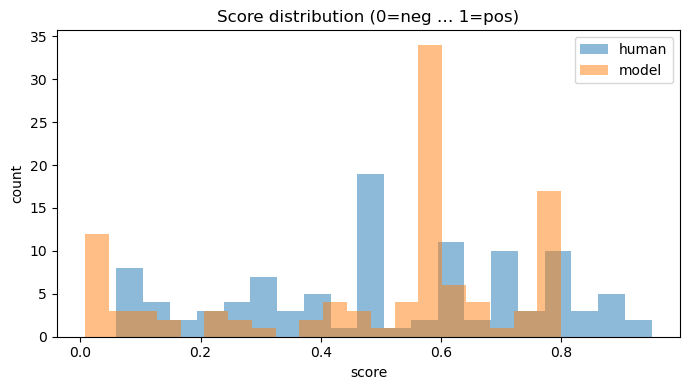

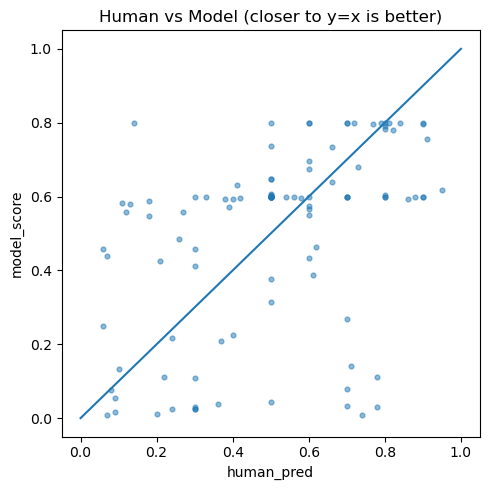

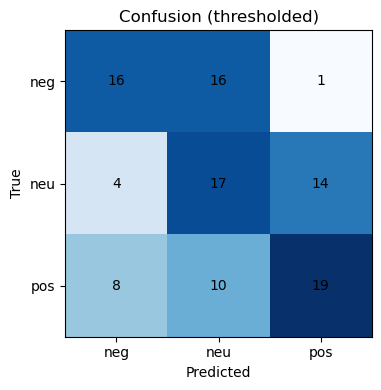

In [63]:
# Rebuild evaluation safely from the CSV

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 0) Load the CSV you exported for human editing
human_path = "human_checked_sample.csv"              # change if needed
dfh = pd.read_csv(human_path)

# 1) Ensure 'human_pred' is numeric and keep only labeled rows
dfh["human_pred"] = pd.to_numeric(dfh.get("human_pred"), errors="coerce")
eval_df = dfh[dfh["human_pred"].notna()].copy()
if eval_df.empty:
    raise SystemExit("No rows have 'human_pred'. Add some decimals (0..1) in human_checked_sample.csv and re-run.")

# 2) Ensure we have model scores; if missing, score now using the sentiment_scorer
if "model_score" not in eval_df.columns:
    from sentiment_scorer import SentimentScorer, SentConfig
    cfg = SentConfig(source="./deberta-financial", subfolder=None, max_len=128, device=None)
    scorer = SentimentScorer(cfg)

    BATCH = 256
    ms = []
    for i in range(0, len(eval_df), BATCH):
        chunk = eval_df.iloc[i:i+BATCH]
        out = scorer.score(chunk["body"].tolist(), return_details=True)
        ms.extend([r["score"] for r in out])
    eval_df["model_score"] = ms

# 3) Create class labels from decimals using thresholds
NEG_T, POS_T = 0.40, 0.60   # adjust if you want a wider/narrower neutral band

def to_class(x: float) -> str:
    if x < NEG_T: return "neg"
    if x > POS_T: return "pos"
    return "neu"

eval_df["human_cls"] = eval_df["human_pred"].map(to_class)
eval_df["model_cls"] = eval_df["model_score"].map(to_class)

# 4) Print metrics
print("Classification report (model vs human):")
print(classification_report(eval_df["human_cls"], eval_df["model_cls"], digits=3))

labels = ["neg","neu","pos"]
cm = confusion_matrix(eval_df["human_cls"], eval_df["model_cls"], labels=labels)

# 5) Plots
# Dist overlay
plt.figure(figsize=(7,4))
eval_df["human_pred"].plot(kind="hist", bins=20, alpha=0.5, label="human")
eval_df["model_score"].plot(kind="hist", bins=20, alpha=0.5, label="model")
plt.title("Score distribution (0=neg … 1=pos)"); plt.xlabel("score"); plt.ylabel("count"); plt.legend(); plt.tight_layout()
plt.show()

# Scatter
plt.figure(figsize=(5,5))
plt.scatter(eval_df["human_pred"], eval_df["model_score"], s=12, alpha=0.5)
plt.plot([0,1],[0,1])
plt.title("Human vs Model (closer to y=x is better)")
plt.xlabel("human_pred"); plt.ylabel("model_score"); plt.tight_layout(); plt.show()

# Confusion heatmap
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(3), labels); plt.yticks(range(3), labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion (thresholded)")
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout(); plt.show()

In [65]:
import numpy as np

def metrics_reg(y_true, y_pred):
    mae  = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true)**2)))
    corr = float(np.corrcoef(y_true, y_pred)[0,1]) if len(y_true) > 1 else np.nan
    return {"n": int(len(y_true)), "mae": mae, "rmse": rmse, "pearson_r": corr}

reg_metrics = metrics_reg(eval_df["human_pred"].to_numpy(), eval_df["model_score"].to_numpy())
reg_metrics


{'n': 105,
 'mae': 0.19628443205001808,
 'rmse': 0.26034571676201035,
 'pearson_r': 0.450203281820908}

In [67]:
merged.to_csv("human_checked_with_model.csv", index=False)
print("[OK] wrote human_checked_with_model.csv")

[OK] wrote human_checked_with_model.csv


In [ ]:
# the combined approach